In [1]:
import sys
from pathlib import Path

parent = Path.cwd().parent
sys.path.append(str(parent))

In [2]:
from src.integrator import ComplexIntegrator
from src.integrand_builder import ContextManager, spherical
import oneloop_bridge
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# do this to trigger the banner here so it doesn't get in the way later
oneloop_bridge.set_renormalization_scale(1.0)

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

In [3]:
cm = ContextManager(force_rebuild = True) 

Compiling evaluator: "combined_result"
Done!


In [4]:
import symbolica


def get_integrals(masses, n_epochs, spe):
    unsub_res = []
    sub_res = []
    
    rng = symbolica.RandomNumberGenerator(0, 0)
    
    for m in tqdm(masses):
        cm.masses = list(m)

        ci3 = ComplexIntegrator(3)
        cm.only_unsubtracted()
        unsub_int = ci3.integrate(cm.eval, spherical,n_epochs=n_epochs, samples_per_epoch=spe, rng=rng)

        ci2 = ComplexIntegrator(3)
        cm.combined_integrand()
        sub_int = ci2.integrate(cm.eval, spherical,n_epochs=n_epochs, samples_per_epoch=spe, rng=rng)

        unsub_res.append(unsub_int)
        sub_res.append(sub_int)
    return unsub_res, sub_res

def get_reference(masses):
    baseline = []
    for m in masses:
        cm.masses = list(m)
        baseline.append(cm.get_reference())
    return np.array(baseline)


In [5]:
def extract_real_avg(l):
    return np.array([x.real_avg for x in l])
    
def extract_real_err(l):
    return np.array([x.real_err for x in l])

def extract_imag_avg(l):
    return np.array([x.imag_avg for x in l])

def extract_imag_err(l):
    return np.array([x.imag_err for x in l])

def plot_convergence(xs, unsub_res, sub_res):
    plt.scatter(xs, unsub_res, label = 'without counterterm')
    plt.scatter(xs, sub_res, label = 'with counterterm')

    plt.ylabel('convergence')
    plt.legend()

100%|██████████| 20/20 [01:53<00:00,  5.70s/it]


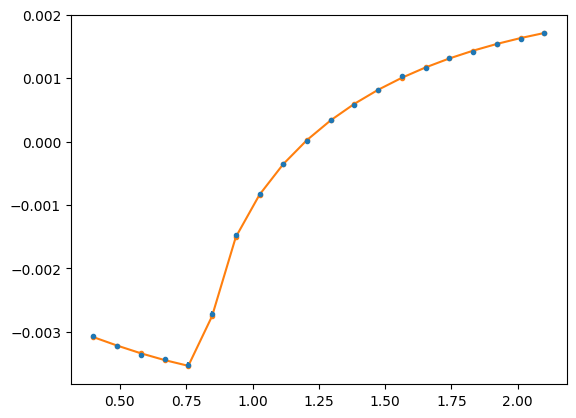

In [6]:
masses = np.linspace(0.4,2.1,20)[:,None]* np.array([1,1.2,0.8])[None,:]
unsub_res, sub_res = get_integrals(masses,n_epochs=50, spe = 500)
reference = get_reference(masses)

plt.errorbar(masses[:,0].real,extract_real_avg(sub_res), extract_real_err(sub_res),label = 'with counterterm', marker = '.', ls = '')
plt.plot(masses[:,0].real,reference.real, label = 'without counterterm', marker = '.')

In [7]:
masses = (0.5-1j*0.75**np.linspace(5,30,10))[:,None] * np.ones(3)[None,:]
unsub_res, sub_res = get_integrals(masses,n_epochs=50, spe = 500)
reference = get_reference(masses)

  0%|          | 0/10 [00:04<?, ?it/s]


KeyboardInterrupt: 

/home/cedric/Uni/thesis/triangler/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/cedric/Uni/thesis/triangler/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


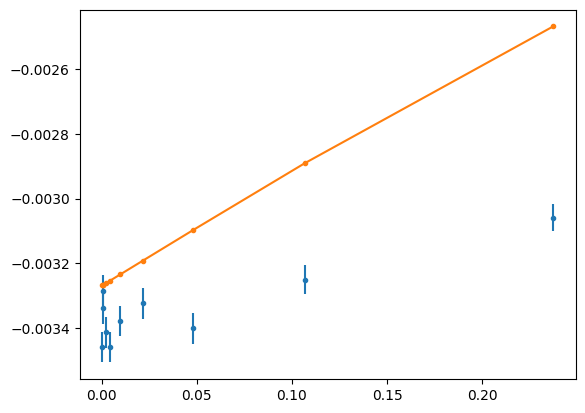

In [ ]:
plt.errorbar(-masses[:,0].imag,extract_real_avg(sub_res), extract_real_err(sub_res),label = 'with counterterm', marker = '.', ls = '')
plt.plot(-masses[:,0].imag,reference, label = 'without counterterm', marker = '.')

In [ ]:
masses = np.linspace(3.499**0.5,3.501**0.5,20)[:,None]* np.ones(3)[None,:]
unsub_res, sub_res = get_integrals(masses,n_epochs=50, spe = 500)
reference = get_reference(masses)

 25%|██▌       | 5/20 [00:05<00:17,  1.20s/it]


KeyboardInterrupt: 

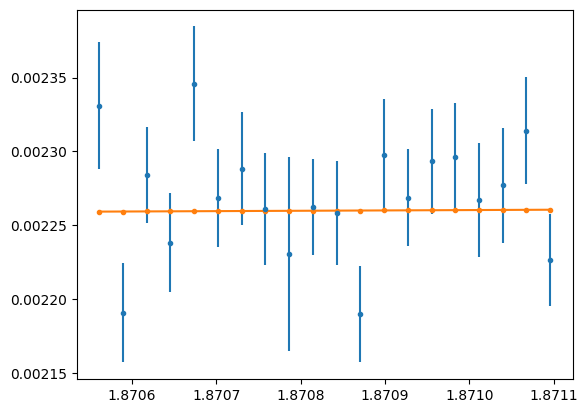

In [ ]:
plt.errorbar(masses[:,0].real,extract_real_avg(sub_res), extract_real_err(sub_res),label = 'with counterterm', marker = '.', ls = '')
plt.plot(masses[:,0].real,reference, label = 'without counterterm', marker = '.')

# set the center such that the origin is not inside the origin

In [ ]:
cm.origin = np.array([0,2,0,0])
masses = np.linspace(0.4,2.1,20)[:,None]* np.ones(3)[None,:]
unsub_res, sub_res = get_integrals(masses,n_epochs=100, spe = 500)
ref_masses = np.linspace(0.4,2.1,200)[:,None]* np.ones(3)[None,:]
reference = get_reference(masses)

100%|██████████| 20/20 [00:41<00:00,  2.05s/it]


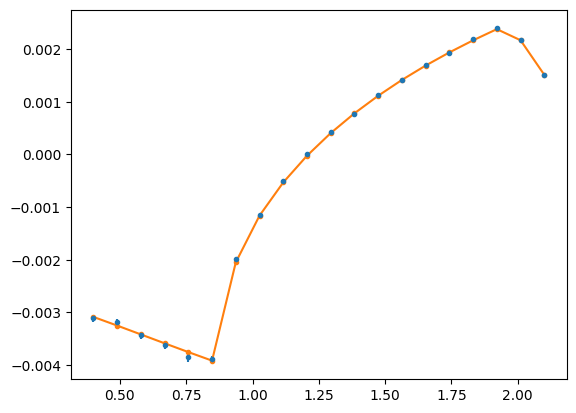

In [ ]:
plt.errorbar(masses[:,0].real,extract_real_avg(sub_res), extract_real_err(sub_res),label = 'with counterterm', marker = '.', ls = '')
plt.plot(masses[:,0].real,reference)

In [ ]:
masses = np.linspace(0.4,2.1,20)[:,None]* np.array([1,1.2,0.8])[None,:]
unsub_res, sub_res = get_integrals(masses,n_epochs=50, spe = 1000)
reference = get_reference(masses)

plt.errorbar(masses[:,0].real,extract_real_avg(sub_res), extract_real_err(sub_res),label = 'with counterterm', marker = '.', ls = '')
plt.plot(masses[:,0].real,reference.real, label = 'without counterterm', marker = '.')

100%|██████████| 20/20 [00:44<00:00,  2.23s/it]


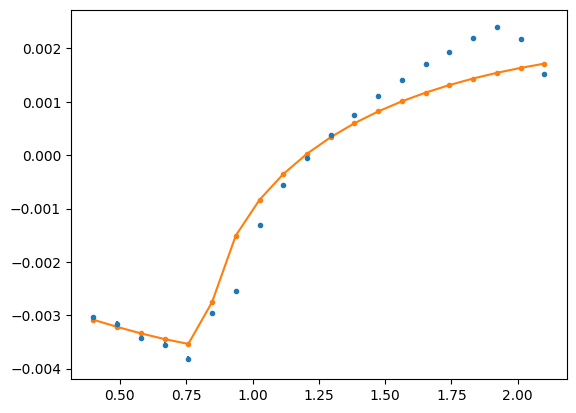